# Predictive Workforce Health: Attrition Risk and AI Influence

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = '/content/drive/MyDrive/ai_worker_burnout_attrition_2026.csv'
data = pd.read_csv(path, index_col='employee_id')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head()

,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,primary_ai_tool,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
employee_id,,,,,,,,,,,,,,,,,,,,
EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,GitHub Copilot,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,ChatGPT,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,Midjourney,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,Perplexity,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,Notion AI,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [ ]:
print("Number of Rows",len(data))
print("Number of Columns",len(data.columns))

Number of Rows 1500
Number of Columns 20


In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().value_counts()

,count
False,1500


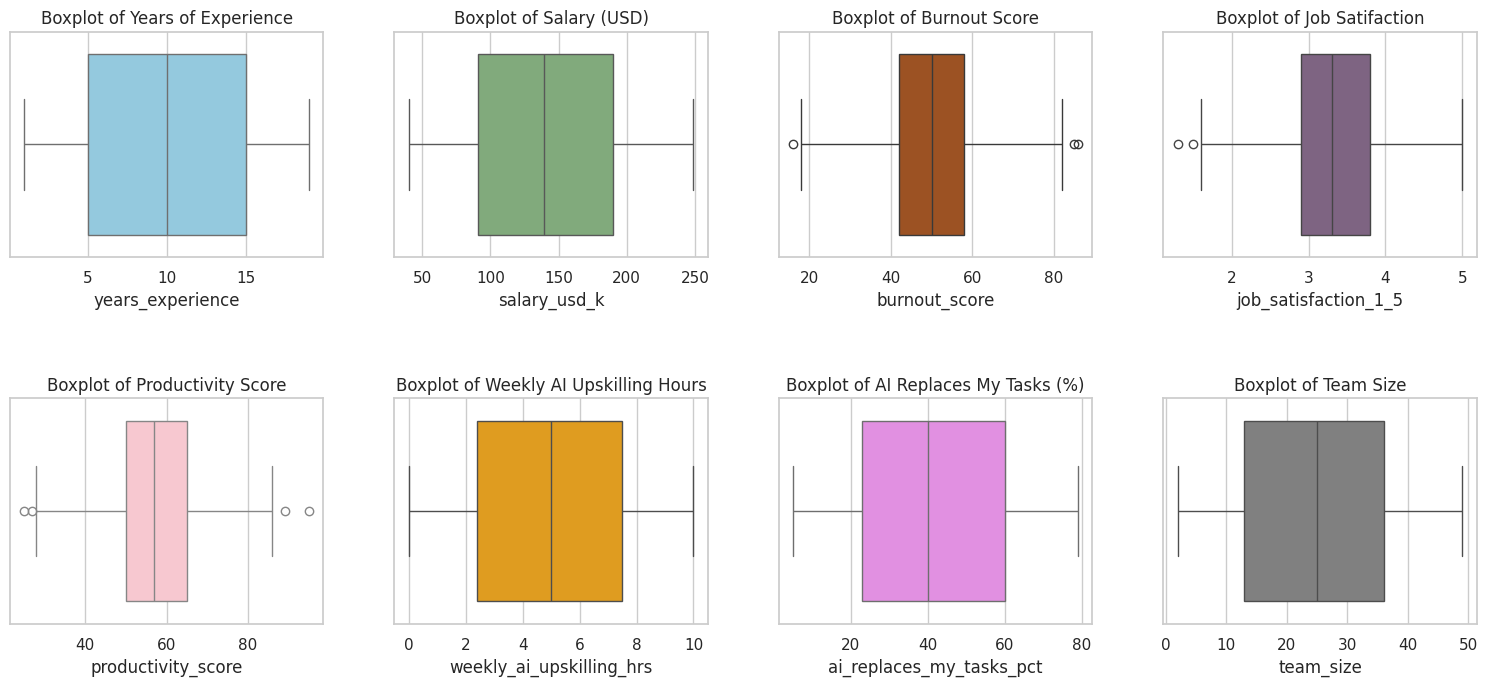

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(16, 8))


plt.subplot(2, 4, 1)
sns.boxplot(x=data['years_experience'], color='skyblue')
plt.title('Boxplot of Years of Experience')

plt.subplot(2, 4, 2)
sns.boxplot(x=data['salary_usd_k'], color='xkcd:faded green')
plt.title('Boxplot of Salary (USD)')

plt.subplot(2, 4, 3)
sns.boxplot(x=data['burnout_score'], color='xkcd:burnt sienna')
plt.title('Boxplot of Burnout Score')

plt.subplot(2, 4, 4)
sns.boxplot(x=data['job_satisfaction_1_5'], color='xkcd:dusty purple')
plt.title('Boxplot of Job Satifaction')

plt.subplot(2, 4, 5)
sns.boxplot(x=data['productivity_score'], color='pink')
plt.title('Boxplot of Productivity Score')

plt.subplot(2, 4, 6)
sns.boxplot(x=data['weekly_ai_upskilling_hrs'], color='orange')
plt.title('Boxplot of Weekly AI Upskilling Hours')

plt.subplot(2, 4, 7)
sns.boxplot(x=data['ai_replaces_my_tasks_pct'], color='violet')
plt.title('Boxplot of AI Replaces My Tasks (%)')

plt.subplot(2, 4, 8)
sns.boxplot(x=data['team_size'], color='grey')
plt.title('Boxplot of Team Size')

plt.tight_layout(pad=4.0)
plt.show()



In [ ]:
import numpy as np
from scipy import stats

def detect_outliers_zscore(df, column_name, threshold=3):
    z_scores = np.abs(stats.zscore(df[column_name]))
    outliers = df[z_scores > threshold]
    return outliers

outliers_years_experience = detect_outliers_zscore(data, 'years_experience')
outliers_salary = detect_outliers_zscore(data, 'salary_usd_k')
outliers_burnout_score = detect_outliers_zscore(data, 'burnout_score')
outliers_job_satisfaction_1_5 = detect_outliers_zscore(data, 'job_satisfaction_1_5')
outliers_productivity_score = detect_outliers_zscore(data, 'productivity_score')
outliers_weekly_ai_upskilling_hrs = detect_outliers_zscore(data, 'weekly_ai_upskilling_hrs')
outliers_ai_replaces_my_tasks_pct = detect_outliers_zscore(data, 'ai_replaces_my_tasks_pct')
outliers_team_size = detect_outliers_zscore(data, 'team_size')


print("\nOutliers Detected (Using Z-Score Threshold > 3):")
print(f"Years of Experience: {len(outliers_years_experience)} outliers")
print(f"Salary (USD): {len(outliers_salary)} outliers")
print(f"Burnout Score: {len(outliers_burnout_score)} outliers")
print(f"Job Satisfaction: {len(outliers_job_satisfaction_1_5)} outliers")
print(f"Productivity Score: {len(outliers_productivity_score)} outliers")
print(f"Weekly AI Upskilling Hours: {len(outliers_weekly_ai_upskilling_hrs)} outliers")
print(f"AI Replaces My Tasks (%): {len(outliers_ai_replaces_my_tasks_pct)} outliers")
print(f"Team Size: {len(outliers_team_size)} outliers")

def cap_outliers(df, column_name, cap_percentile=0.99):
    cap_value = df[column_name].quantile(cap_percentile)
    df[column_name] = df[column_name].apply(lambda x: min(x, cap_value))



Outliers Detected (Using Z-Score Threshold > 3):
Years of Experience: 0 outliers
Salary (USD): 0 outliers
Burnout Score: 2 outliers
Job Satisfaction: 1 outliers
Productivity Score: 2 outliers
Weekly AI Upskilling Hours: 0 outliers
AI Replaces My Tasks (%): 0 outliers
Team Size: 0 outliers


In [ ]:
def remove_outliers_zscore(df, column_name, threshold=3):
    z_scores = np.abs(stats.zscore(df[column_name]))
    df_clean = df[z_scores <= threshold]
    return df_clean

columns = ['burnout_score','job_satisfaction_1_5','productivity_score']

for col in columns:
    data = remove_outliers_zscore(data, col)

In [ ]:
len(data)

1495

In [ ]:
data.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,9.958528,24.817391,140.749164,4.054181,4.230502,41.208696,4.983813,57.529097,50.003344,3.336856
std,5.461036,13.690917,59.744699,1.973487,2.147591,21.659419,2.913196,10.654376,11.360910,0.634167
min,1.000000,2.000000,40.000000,1.000000,0.500000,5.000000,0.000000,27.000000,16.000000,1.500000
25%,5.000000,13.000000,91.000000,2.000000,2.400000,22.000000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.000000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.000000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.000000,8.000000,79.000000,10.000000,89.000000,82.000000,5.000000


In [ ]:
data.select_dtypes(include=['object']).describe()

,job_role,education_level,country,industry,company_size,remote_work_type,primary_ai_tool,ai_adoption_stage,fear_of_ai_replacement,attrition_risk
count,1495,1495,1495,1495,1495,1495,1495,1495,1495,1495
unique,12,5,10,10,5,3,8,4,3,3
top,Software Engineer,Master,France,EdTech,Mid (200-1000),Hybrid,Midjourney,Integrating,Medium,Low
freq,147,322,177,170,315,597,213,490,619,722


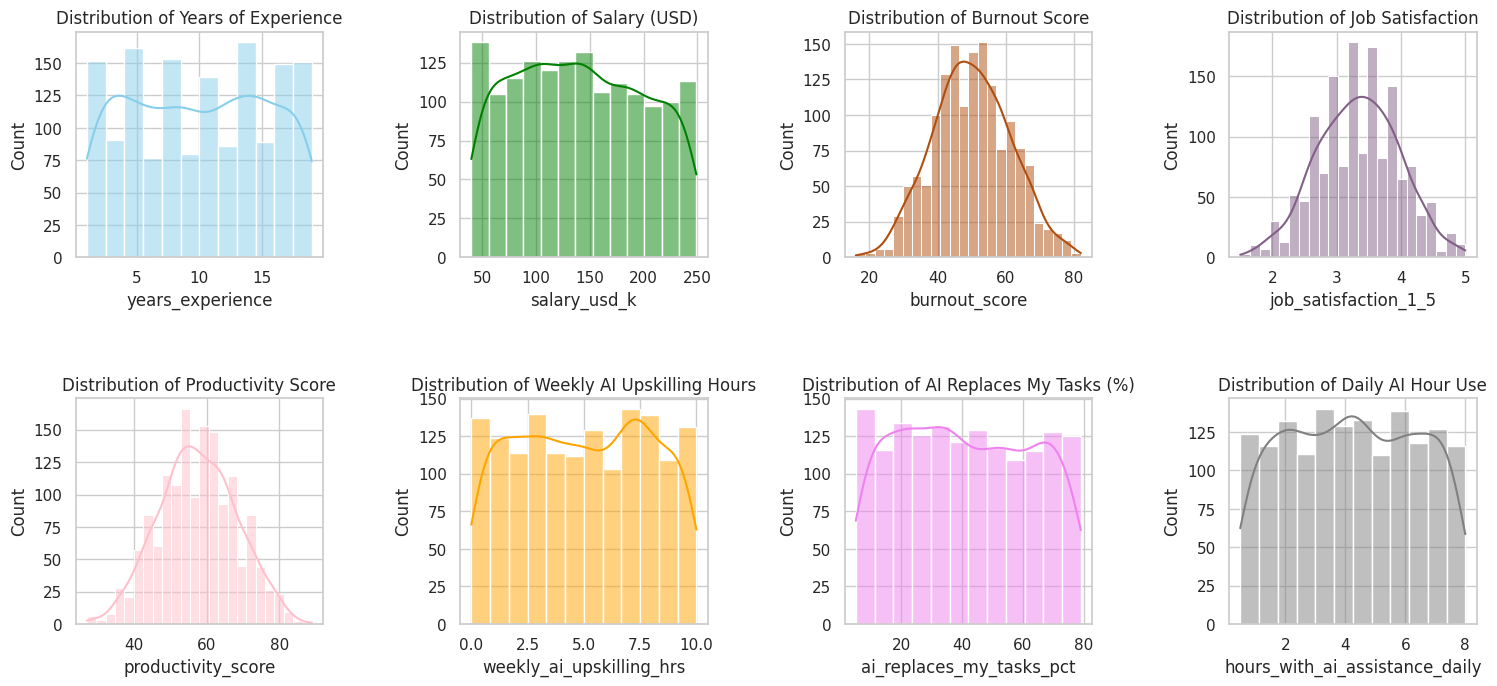

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
sns.histplot(data['years_experience'], kde=True, color='skyblue')
plt.title('Distribution of Years of Experience')

plt.subplot(2, 4, 2)
sns.histplot(data['salary_usd_k'], kde=True, color='green')
plt.title('Distribution of Salary (USD)')

plt.subplot(2, 4, 3)
sns.histplot(data['burnout_score'], kde=True, color='xkcd:burnt sienna')
plt.title('Distribution of Burnout Score')

plt.subplot(2, 4, 4)
sns.histplot(data['job_satisfaction_1_5'], kde=True, color='xkcd:dusty purple')
plt.title('Distribution of Job Satisfaction')

plt.subplot(2, 4, 5)
sns.histplot(data['productivity_score'], kde=True, color='pink')
plt.title('Distribution of Productivity Score')

plt.subplot(2, 4, 6)
sns.histplot(data['weekly_ai_upskilling_hrs'], kde=True, color='orange')
plt.title('Distribution of Weekly AI Upskilling Hours')

plt.subplot(2, 4, 7)
sns.histplot(data['ai_replaces_my_tasks_pct'], kde=True, color='violet')
plt.title('Distribution of AI Replaces My Tasks (%)')

plt.subplot(2, 4, 8)
sns.histplot(data['hours_with_ai_assistance_daily'], kde=True, color='grey')
plt.title('Distribution of Daily AI Hour Use')

plt.tight_layout(pad=4.0)
plt.show()


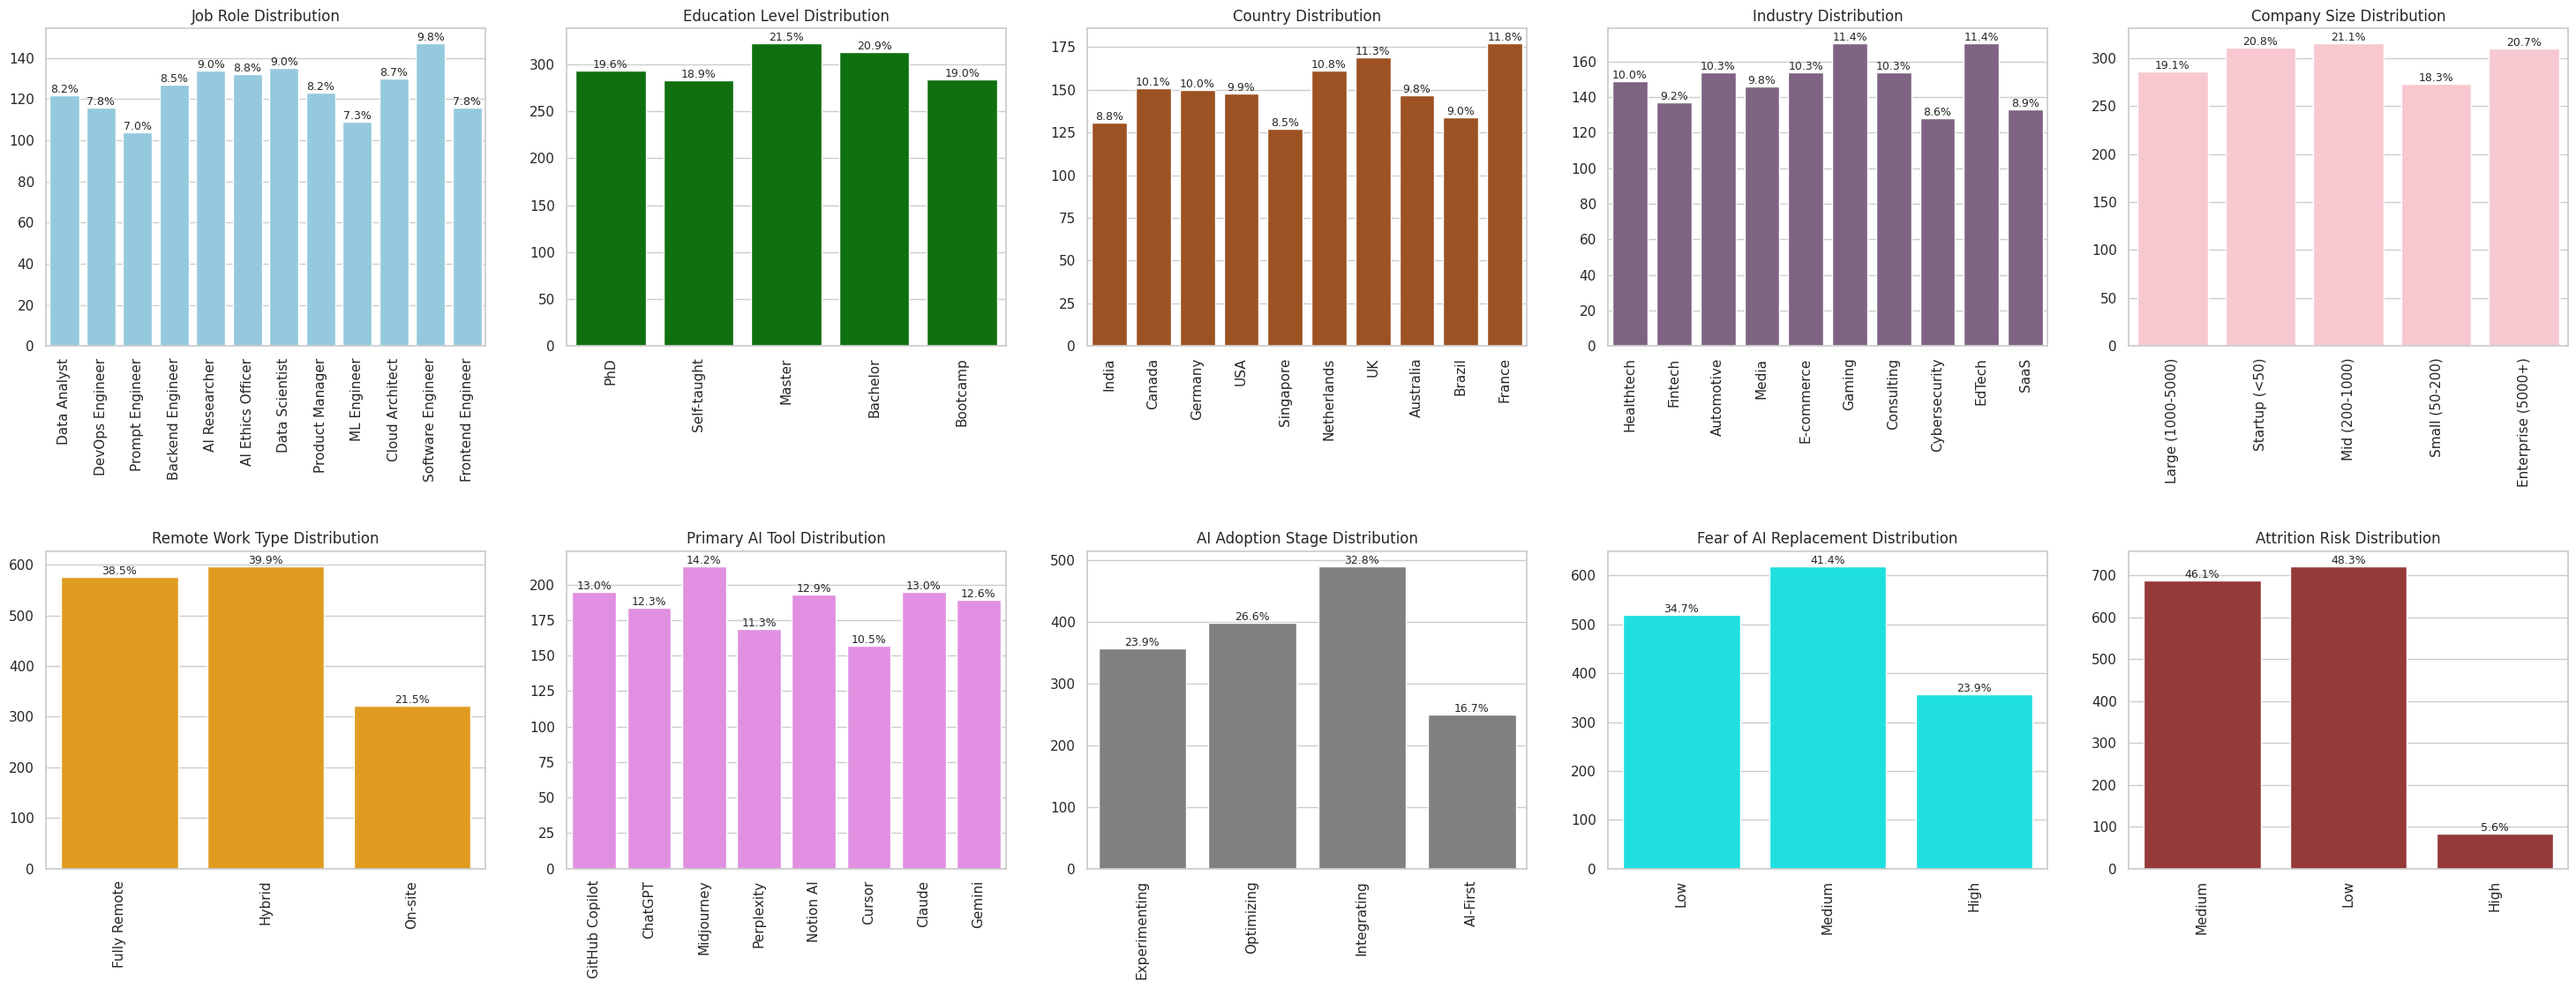

In [ ]:
plt.figure(figsize=(30, 12))

def add_percentage(ax, data):
    total = len(data)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)


plt.subplot(2, 5, 1)
ax = sns.countplot(x='job_role', data=data, color='skyblue')
plt.title('Job Role Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2,5, 2)
ax = sns.countplot(x='education_level', data=data, color='green')
plt.title('Education Level Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 3)
ax = sns.countplot(x='country', data=data, color='xkcd:burnt sienna')
plt.title('Country Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 4)
ax = sns.countplot(x='industry', data=data, color='xkcd:dusty purple')
plt.title('Industry Distribution')
plt.xticks(rotation=90)
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 5)
ax = sns.countplot(x='company_size', data=data, color='pink')
plt.title('Company Size Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5,6)
ax = sns.countplot(x='remote_work_type', data=data, color='orange')
plt.title('Remote Work Type Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 7)
ax = sns.countplot(x='primary_ai_tool', data=data, color='violet')
plt.title('Primary AI Tool Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 8)
ax = sns.countplot(x='ai_adoption_stage', data=data, color='grey')
plt.title('AI Adoption Stage Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 9)
ax = sns.countplot(x='fear_of_ai_replacement', data=data, color='cyan')
plt.title('Fear of AI Replacement Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.subplot(2, 5, 10)
ax = sns.countplot(x='attrition_risk', data=data, color='brown')
plt.title('Attrition Risk Distribution')
plt.xticks(rotation=90)
ax.set(xlabel=None, ylabel=None)
add_percentage(ax, data)

plt.tight_layout(pad=3.0)
plt.show()

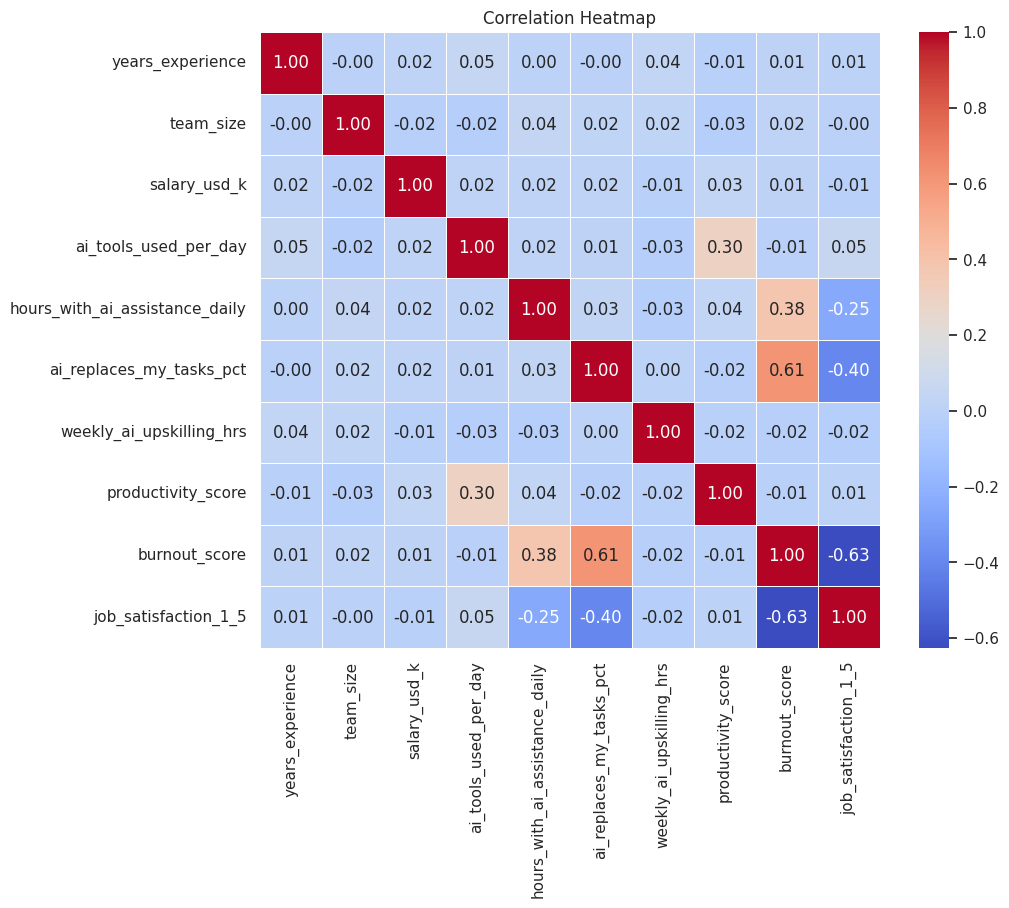

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 8))
numerical_data = data.select_dtypes(include=['number'])
correlation_matrix = numerical_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
pivot_salary_job_role = pd.pivot_table(data, values='salary_usd_k', index='job_role', columns='attrition_risk', aggfunc='mean')
print("\nAverage Salary by Job Role and Attrition Risk")
pivot_salary_job_role


Average Salary by Job Role and Attrition Risk


attrition_risk,High,Low,Medium
job_role,,,
AI Ethics Officer,140.153846,146.818182,149.943396
AI Researcher,133.500000,127.762712,140.318841
Backend Engineer,157.333333,146.800000,121.568966
Cloud Architect,144.500000,153.044776,140.964912
Data Analyst,163.714286,148.036364,148.666667
Data Scientist,168.333333,140.451613,141.942857
DevOps Engineer,125.222222,142.603448,137.775510
Frontend Engineer,124.428571,131.209677,130.851064
ML Engineer,139.666667,137.708333,132.272727


In [ ]:
pivot_job_attrition = pd.pivot_table(
    data,
    index='job_role',
    columns='attrition_risk',
    aggfunc='size',
    fill_value=0
)
pivot_job_attrition

attrition_risk,High,Low,Medium
job_role,,,
AI Ethics Officer,13,66,53
AI Researcher,6,59,69
Backend Engineer,9,60,58
Cloud Architect,6,67,57
Data Analyst,7,55,60
Data Scientist,3,62,70
DevOps Engineer,9,58,49
Frontend Engineer,7,62,47
ML Engineer,6,48,55


In [ ]:
pivot_ai_attrition = pd.pivot_table(
    data,
    index='fear_of_ai_replacement',
    columns='attrition_risk',
    aggfunc='size',
    fill_value=0
)
pivot_ai_attrition

attrition_risk,High,Low,Medium
fear_of_ai_replacement,,,
High,78,23,256
Low,4,318,197
Medium,2,381,236


In [ ]:
pivot_satisfaction = pd.pivot_table(
    data,
    values='job_satisfaction_1_5',
    index='attrition_risk',
    aggfunc='mean'
)
pivot_satisfaction

,job_satisfaction_1_5
attrition_risk,
High,2.660714
Low,3.687119
Medium,3.052250


In [ ]:
pivot_burnout = pd.pivot_table(
    data,
    values='burnout_score',
    index='attrition_risk',
    aggfunc='mean'
)
pivot_burnout

,burnout_score
attrition_risk,
High,60.500000
Low,44.034626
Medium,54.978229


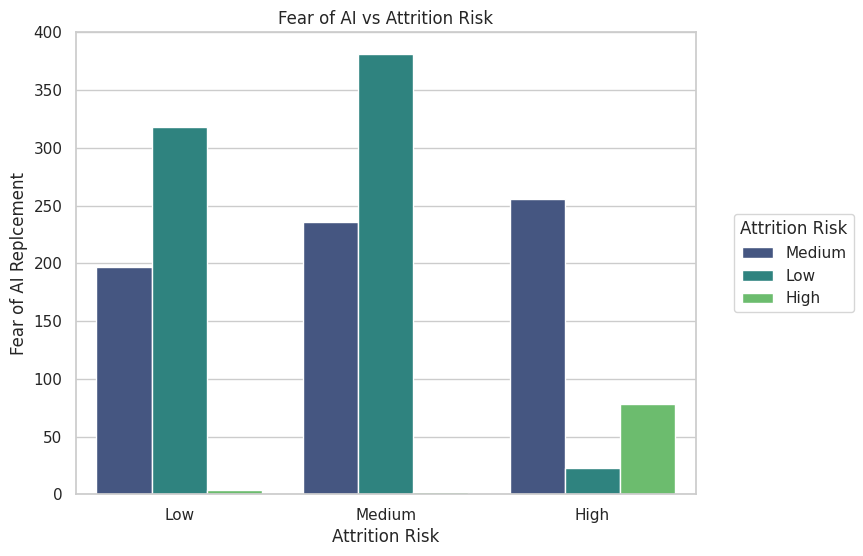

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='fear_of_ai_replacement', hue='attrition_risk', data=data, palette="viridis")
plt.title('Fear of AI vs Attrition Risk')
plt.xlabel("Attrition Risk")
plt.ylabel("Fear of AI Replcement")
plt.legend(title='Attrition Risk', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

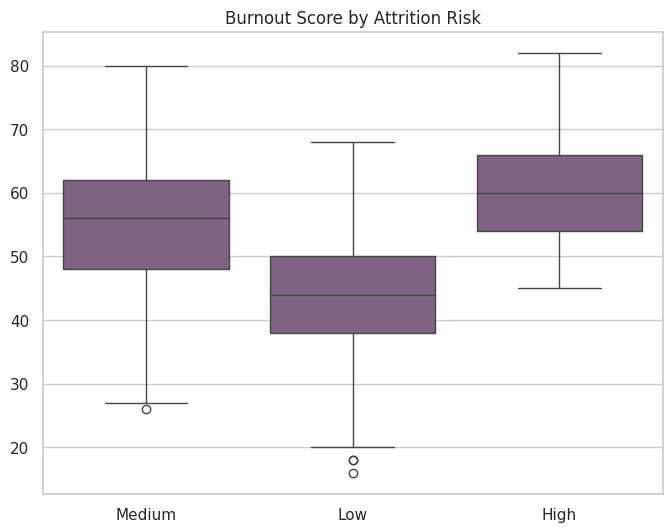

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='attrition_risk', y='burnout_score', data=data,color='xkcd:dusty purple')
plt.title('Burnout Score by Attrition Risk')
plt.xlabel('')
plt.ylabel('')
plt.show()

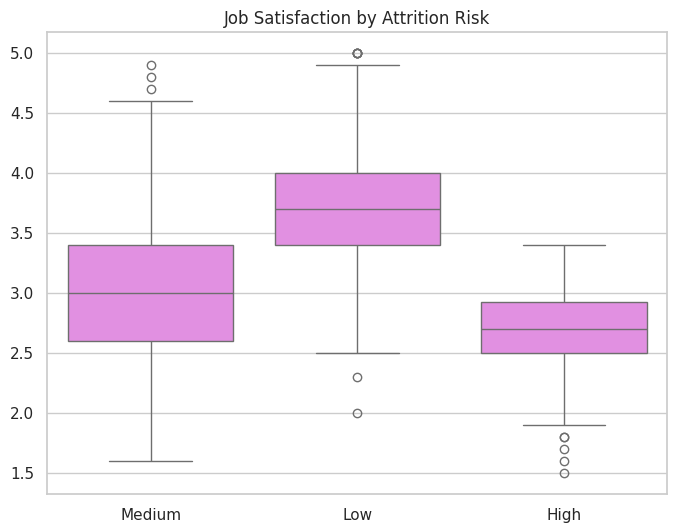

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='attrition_risk', y='job_satisfaction_1_5', data=data, color="violet")
plt.title('Job Satisfaction by Attrition Risk')
plt.xlabel('')
plt.ylabel('')
plt.show()

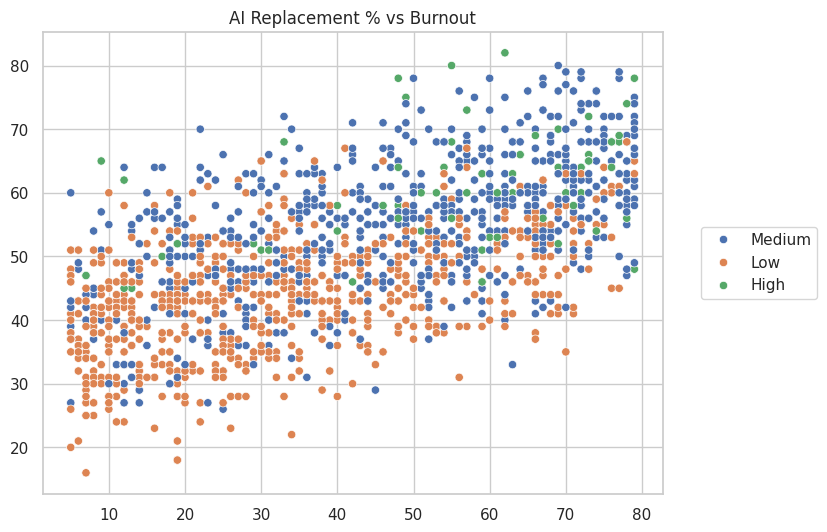

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='ai_replaces_my_tasks_pct',
    y='burnout_score',
    hue='attrition_risk',
    data=data
)
plt.title('AI Replacement % vs Burnout')
plt.xlabel('')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

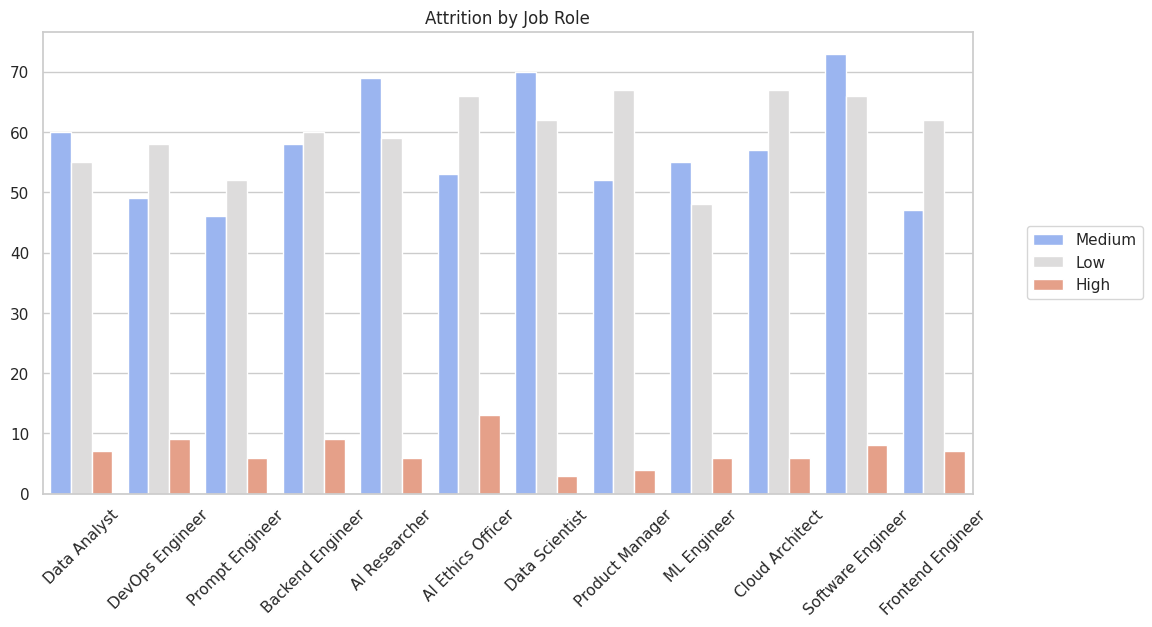

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='job_role', hue='attrition_risk', data=data,palette="coolwarm")
plt.xticks(rotation=45)
plt.title('Attrition by Job Role')
plt.xlabel('')
plt.ylabel('')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

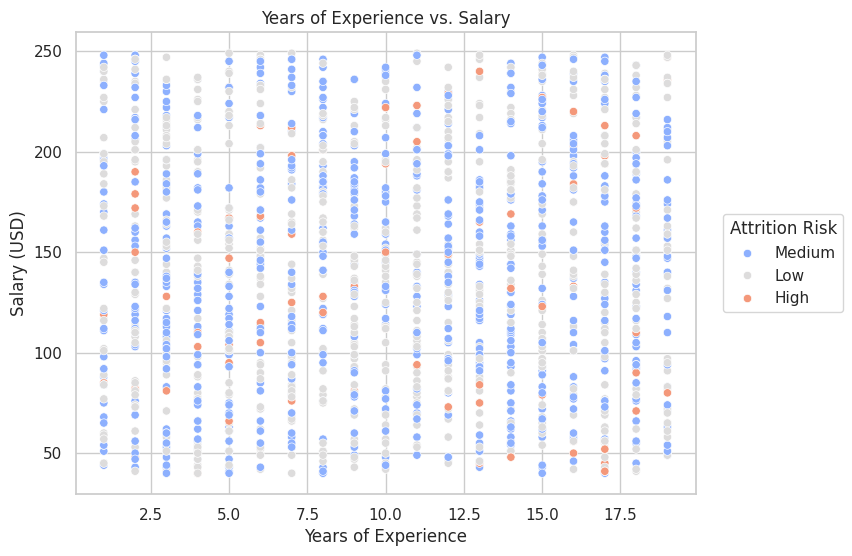

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='years_experience', y='salary_usd_k', data=data, hue='attrition_risk', palette='coolwarm')
plt.title('Years of Experience vs. Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (USD)')
plt.legend(loc='center right', bbox_to_anchor=(1.25, 0.5), title='Attrition Risk')
plt.show()

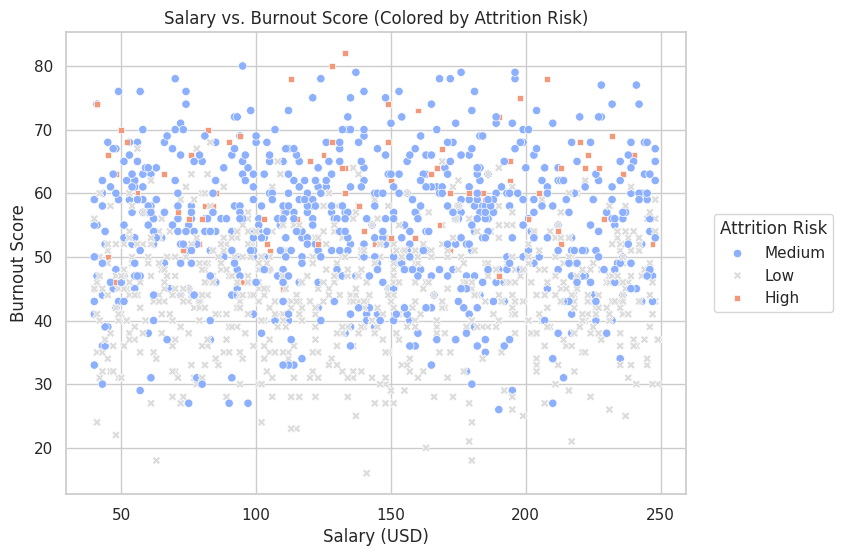

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='salary_usd_k', y='burnout_score', data=data, hue='attrition_risk', style='attrition_risk', palette='coolwarm')
plt.title('Salary vs. Burnout Score (Colored by Attrition Risk)')
plt.xlabel('Salary (USD)')
plt.ylabel('Burnout Score')
plt.legend(loc='center right', bbox_to_anchor=(1.25, 0.5), title='Attrition Risk')
plt.show()

/tmp/ipykernel_7547/716455755.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='attrition_risk', y='burnout_score', data=data, palette="vlag")


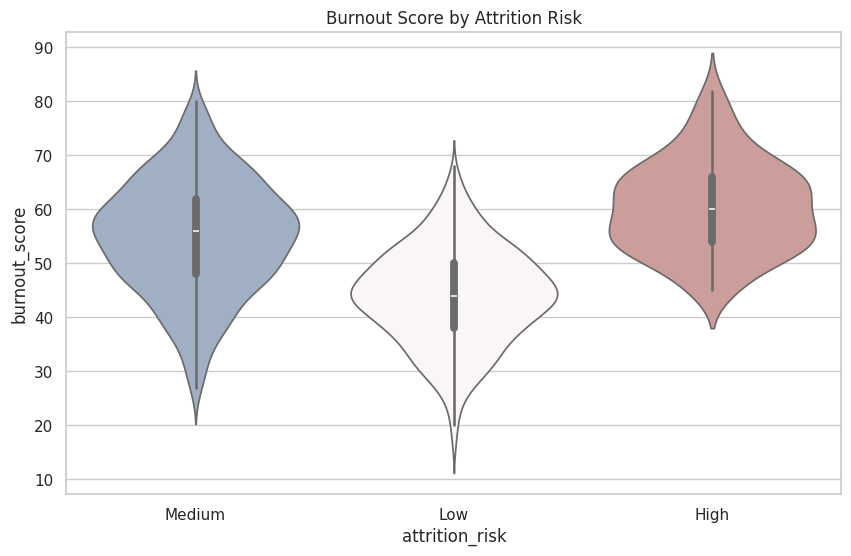

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='attrition_risk', y='burnout_score', data=data, palette="vlag")
plt.title("Burnout Score by Attrition Risk")
plt.show()

/tmp/ipykernel_7547/3530842651.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_role', y='salary_usd_k', data=data, palette="coolwarm")


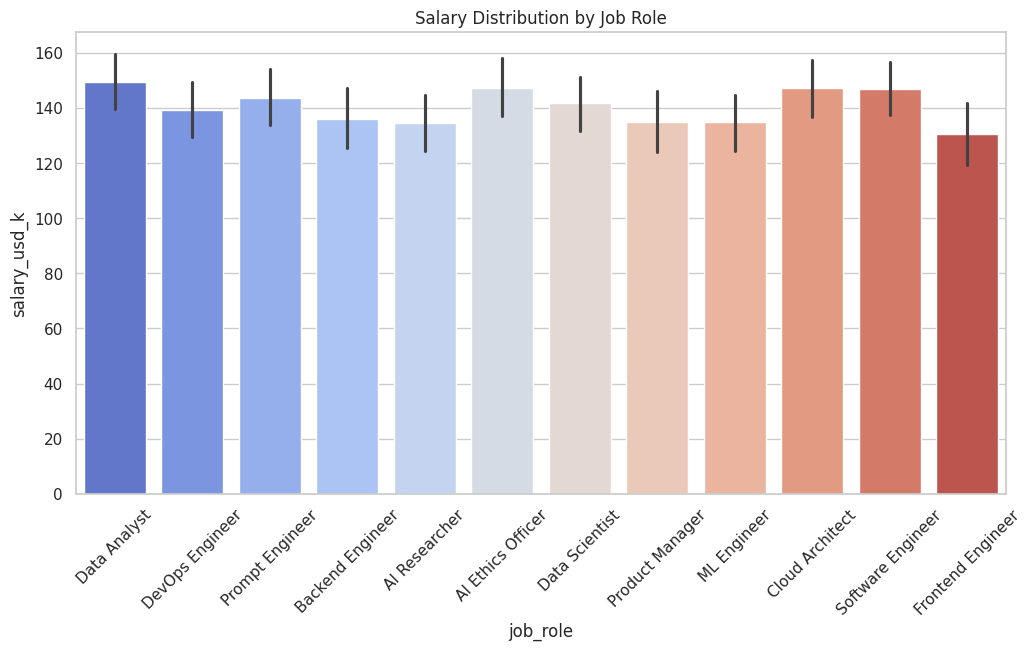

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='job_role', y='salary_usd_k', data=data, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Salary Distribution by Job Role")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
le = LabelEncoder()

categorical_cols = ['job_role','education_level','country','industry','company_size',
    'remote_work_type','primary_ai_tool','ai_adoption_stage','fear_of_ai_replacement','attrition_risk' ]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [ ]:
X = data[['industry','job_role','company_size','ai_adoption_stage','fear_of_ai_replacement',
          'burnout_score','productivity_score', 'job_satisfaction_1_5','salary_usd_k','remote_work_type','country']]

y = data['attrition_risk']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=4)

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy: 0.7959866220735786
              precision    recall  f1-score   support

           0       0.73      0.52      0.61        21
           1       0.85      0.83      0.84       145
           2       0.75      0.80      0.78       133

    accuracy                           0.80       299
   macro avg       0.78      0.72      0.74       299
weighted avg       0.80      0.80      0.79       299



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Results
Accuracy: 0.8729096989966555
              precision    recall  f1-score   support

           0       0.85      0.52      0.65        21
           1       0.92      0.90      0.91       145
           2       0.83      0.90      0.86       133

    accuracy                           0.87       299
   macro avg       0.87      0.77      0.81       299
weighted avg       0.87      0.87      0.87       299



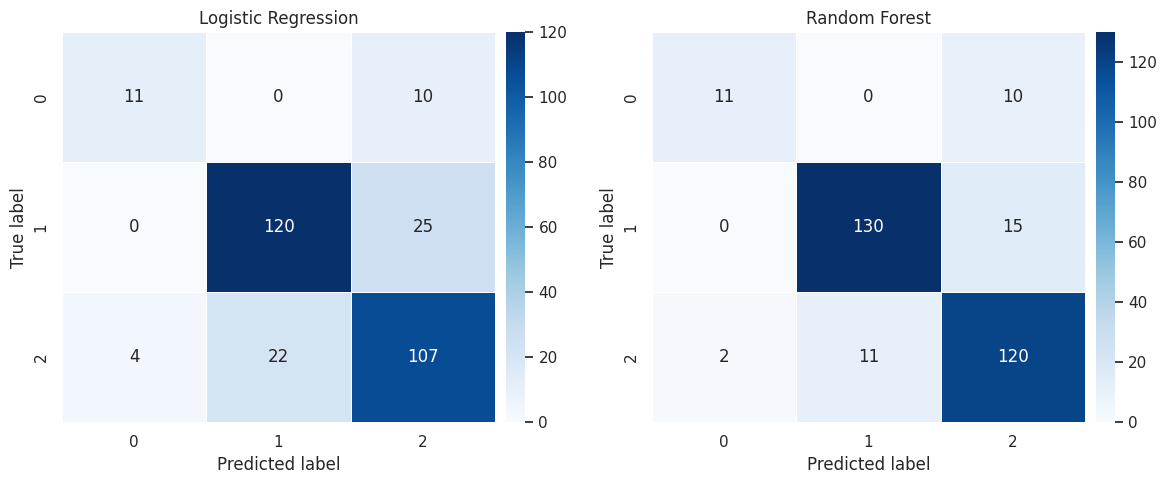

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

cm_lr = confusion_matrix(y_test, lr_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_lr,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=True,
            ax=ax[0],
            linewidths=0.5,
            linecolor='white',
            cbar_kws={"pad": 0.02})

ax[0].set_title("Logistic Regression")
ax[0].set_xlabel("Predicted label")
ax[0].set_ylabel("True label")
ax[0].grid(False)

# Random Forest
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=True,
            ax=ax[1],
            linewidths=0.5,
            linecolor='white',
            cbar_kws={"pad": 0.02})

ax[1].set_title("Random Forest")
ax[1].set_xlabel("Predicted label")
ax[1].set_ylabel("True label")
ax[1].grid(False)

plt.tight_layout()
plt.show()

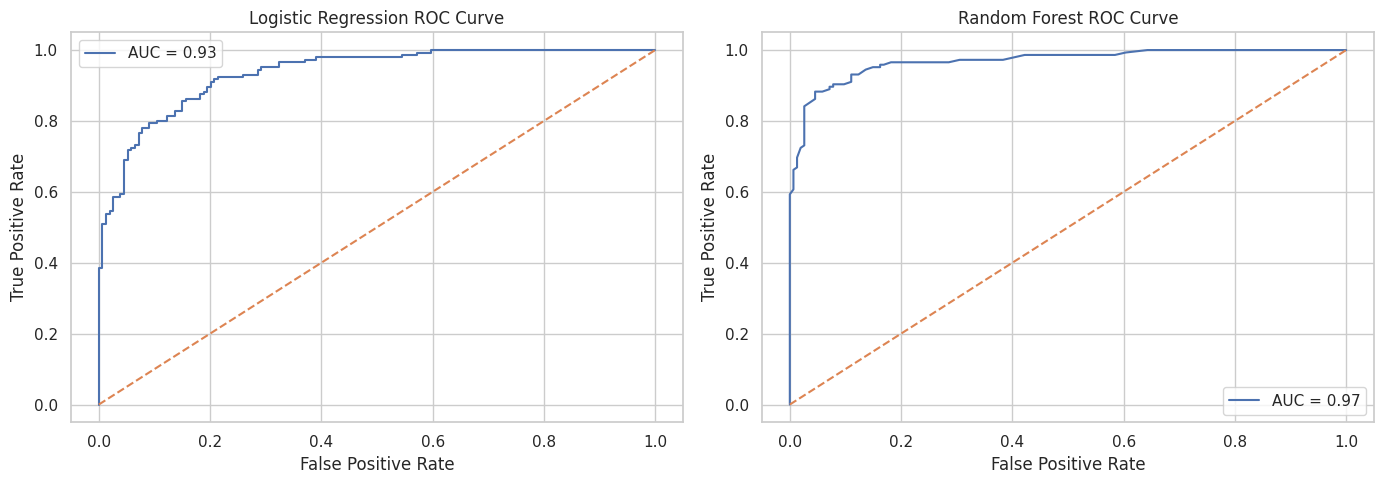

In [ ]:
from sklearn.metrics import roc_curve, auc

lr_probs = lr_model.predict_proba(X_test)
rf_probs = rf_model.predict_proba(X_test)


fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    lr_probs[:, 1],
    pos_label=1
)

auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs[:, 1],
    pos_label=1
)

auc_rf = auc(fpr_rf, tpr_rf)



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    fpr_lr,
    tpr_lr,
    label=f'AUC = {auc_lr:.2f}'
)

axes[0].plot([0,1], [0,1], linestyle='--')

axes[0].set_title("Logistic Regression ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(
    fpr_rf,
    tpr_rf,
    label=f'AUC = {auc_rf:.2f}'
)

axes[1].plot([0,1], [0,1], linestyle='--')

axes[1].set_title("Random Forest ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
features = ['job_satisfaction_1_5','productivity_score','burnout_score','salary_usd_k',
            'years_experience','ai_replaces_my_tasks_pct','weekly_ai_upskilling_hrs','hours_with_ai_assistance_daily']

X = data[features]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans( n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['Cluster'] = clusters

In [ ]:
cluster_sizes = data['Cluster'].value_counts()
cluster_sizes

,count
Cluster,
2,543
1,512
0,440


In [ ]:
cluster_summary = data.groupby('Cluster')[features].mean()
cluster_summary

,job_satisfaction_1_5,productivity_score,burnout_score,salary_usd_k,years_experience,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,hours_with_ai_assistance_daily
Cluster,,,,,,,,
0,3.404773,60.113636,48.861364,144.179545,9.688636,29.461364,4.328864,5.971591
1,2.803516,56.126953,60.929688,140.156250,9.976562,61.748047,5.312695,4.696680
2,3.784715,56.756906,40.626151,138.528545,10.160221,31.360958,5.204420,2.380110
